In [113]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [114]:
## 데이터 불러오기
portfolio = pd.read_csv('/Users/joshuakim/Desktop/Project 3 data/Starbucks Data/portfolio.csv')
profile = pd.read_csv('/Users/joshuakim/Desktop/Project 3 data/Starbucks Data/profile.csv')
transcript = pd.read_csv('/Users/joshuakim/Desktop/Project 3 data/Starbucks Data/transcript.csv')

In [115]:
# Portfolit 데이터 간단하게 확인하기 
portfolio.shape #(10,7)
portfolio.info()
portfolio.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10 non-null     int64 
 1   reward      10 non-null     int64 
 2   channels    10 non-null     object
 3   difficulty  10 non-null     int64 
 4   duration    10 non-null     int64 
 5   offer_type  10 non-null     object
 6   id          10 non-null     object
dtypes: int64(4), object(3)
memory usage: 692.0+ bytes


,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [116]:
# Profile 데이터 간단하게 확인하기 
profile.shape # (17000,6)
profile.info()
profile.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  object 
 2   age               17000 non-null  int64  
 3   id                17000 non-null  object 
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 797.0+ KB


,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
5,5,M,68,e2127556f4f64592b11af22de27a7932,20180426,70000.0
6,6,NaN,118,8ec6ce2a7e7949b1bf142def7d0e0586,20170925,NaN
7,7,NaN,118,68617ca6246f4fbc85e91a2a49552598,20171002,NaN
8,8,M,65,389bc3fa690240e798340f5a15918d5c,20180209,53000.0
9,9,NaN,118,8974fc5686fe429db53ddde067b88302,20161122,NaN


In [117]:
# Transcript 데이터 간단하게 확인하기 
transcript.shape #(306534,5)
transcript.info()
transcript.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  306534 non-null  int64 
 1   person      306534 non-null  object
 2   event       306534 non-null  object
 3   value       306534 non-null  object
 4   time        306534 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.7+ MB


,Unnamed: 0,person,event,value,time
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
5,5,389bc3fa690240e798340f5a15918d5c,offer received,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},0
6,6,c4863c7985cf408faee930f111475da3,offer received,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},0
7,7,2eeac8d8feae4a8cad5a6af0499a211d,offer received,{'offer id': '3f207df678b143eea3cee63160fa8bed'},0
8,8,aa4862eba776480b8bb9c68455b8c2e1,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
9,9,31dda685af34476cad5bc968bdb01c53,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0


In [118]:
# 결측치 확인하기
#df.isnull().sum().sort_values(ascending=False)
profile.isnull().sum().sort_values(ascending=False)
#df3.isnull().sum().sort_values(ascending=False)

# Profile 데이터(df2)에서 null값 2175개 확인 -> gender, income

gender              2175
income              2175
Unnamed: 0             0
age                    0
id                     0
became_member_on       0
dtype: int64

In [119]:
# profile 데이터 age 부분 확인
# 118세 -> 2175명인데 이거는 말이 안됨 -> 찾아보니깐 스타벅스에서 임의로 지정한 값(설문조사할때 나이를 안밝힌 사람들을 118로 지칭)
# 118세를 제외하더라도 100세 101세 96세등 좀 말이 안되는 나이대가 있음 -> 이거를 어떻게 할까??? (10대 20대 30대 이렇게한다면 어디까지 묶을 것인지??)
# 상식적으로 말이 안되는 나이를 우리가 임의로 지정하여 제외하고 볼것인지 -> 문제가 118세 사람들은 나이가 없는데 이사람들도 빼고 진행할건지 임이의 값을 지정해주고 진행할건지
# -> 17000명 중에 2175명이면 데이터의 많은 부분 차지 

profile["age"].value_counts(ascending=False)

age
118    2175
58      408
53      372
51      363
54      359
       ... 
100      12
96        8
98        5
101       5
99        5
Name: count, Length: 85, dtype: int64

In [120]:
# 90세이상이 얼마나 있을까??
(profile["age"] >= 90).sum()
(profile["age"] >= 90).mean()
profile[profile["age"] >= 90]["age"].value_counts().sort_index()

age
90       52
91       47
92       40
93       29
94       33
95       22
96        8
97       13
98        5
99        5
100      12
101       5
118    2175
Name: count, dtype: int64

In [121]:
# profile 데이터 income(수익) 부분 확인
# null 값이 2175로 age = 118이랑 동일하다
profile["income"].value_counts(dropna=False)

income
NaN         2175
73000.0      314
72000.0      297
71000.0      294
57000.0      288
            ... 
116000.0      46
107000.0      45
112000.0      45
117000.0      32
120000.0      13
Name: count, Length: 92, dtype: int64

In [122]:
# Profile 데이터의 gender(성) 부분 확인
# Male = 8484명, Female = 6129명, null값 = 2175명 그리고 O?? = 212명 -> O는 뭘까?? 트렌스젠더?? 
# null값이랑 118세랑 income하고 겹친다 -> 다같이 null
profile["gender"].value_counts(dropna=False)

gender
M      8484
F      6129
NaN    2175
O       212
Name: count, dtype: int64

In [123]:
# gender가 O인 행들을 함 보기
# gender 빼고는 다 정상인거 같음
profile[profile["gender"] == "O"]
profile[profile["gender"] == "O"][["age","income"]].describe()

,age,income
count,212.000000,212.000000
mean,54.400943,63287.735849
std,16.244710,18938.594726
min,20.000000,30000.000000
25%,43.000000,51000.000000
50%,55.000000,62000.000000
75%,66.000000,79250.000000
max,100.000000,100000.000000


In [124]:
# Profile 데이터의 income 부분 확인
# 49000이하 / 49000 ~ 64000 / 64000 ~ 80000 / 80000 ~ 100000 / 100000이상  
profile["income"].describe()

count     14825.000000
mean      65404.991568
std       21598.299410
min       30000.000000
25%       49000.000000
50%       64000.000000
75%       80000.000000
max      120000.000000
Name: income, dtype: float64

In [125]:
# Profile 데이터의 id 부분 확인 -> 혹시나 중복 아이디가 있나해서 확인
# 중복 아이디 없음
profile["id"].value_counts(ascending=False)

id
68be06ca386d4c31939f3a4f0e3dd783    1
a1183510d48a4ebfa68a19e2340ea6d9    1
128c0040b8d34587970e1cbbf60f5cc0    1
1be96fc7edd14e428addbbdc7eccdd27    1
4018381562d645bca291b2ea87413258    1
                                   ..
3fd1c26b6323485da797981fe792204c    1
705644ad87c44c09bfc8162c85ec7368    1
4d4b57c45d834cd79bf78f6fcc7c1c2c    1
48a31c17273d476c87571c44ddf3e667    1
e4052622e5ba45a8b96b59aba68cf068    1
Name: count, Length: 17000, dtype: int64

In [126]:
# Profile 데이터의 became_member_on 부분 확인 -> 언제 가입했는지
# 2013/09/22일이 제일 빠른 맴버 가입날짜 / 2017/12/07일이 제일 최근 맴버 가입 날짜 
# 이상한거는 제일 처음이 2013년9월22일 1명 그다음이 2014년10월23일 1명 -> 옛날에 맴버 가입했던 사람들은 설문 조사를 참여 많이 안함 -> 마케팅 효과 못봤을 수도
# 나중에 빨리 맴버가입한 사람들중에서 이벤트효과정도를 봐야할거 같음 2017년도 사람들이 많이 영향을 받을걸 보아
profile["became_member_on"].value_counts()

became_member_on
20171207    43
20170819    42
20171007    40
20171113    39
20170928    38
            ..
20141212     1
20140412     1
20140621     1
20141023     1
20130922     1
Name: count, Length: 1716, dtype: int64

In [127]:
# transcript 데이터의 person 부분 확인
# 숫자가 높을수록 거래 또는 이벤트에 많이 노출됬을 확률이 큼 
transcript["person"].value_counts(ascending=False)

person
94de646f7b6041228ca7dec82adb97d2    51
8dbfa485249f409aa223a2130f40634a    49
d0a80415b84c4df4908b8403b19765e3    48
5e60c6aa3b834e44b822ea43a3efea26    48
79d9d4f86aca4bed9290350fb43817c2    48
                                    ..
afd41b230f924f9ca8f5ed6249616114     2
3a4e53046c544134bb1e7782248631d1     2
e63e42480aae4ede9f07cac49c8c3f78     2
7ecfc592171f4844bdc05bdbb48d3847     2
da7a7c0dcfcb41a8acc7864a53cf60fb     1
Name: count, Length: 17000, dtype: int64

In [128]:
# transcript 데이터의 event 부분 확인
transcript["event"].value_counts()

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64

In [129]:
# transcript 데이터의 value 부분 확인
transcript["value"].value_counts(ascending=False)

value
{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'}    14983
{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}    14924
{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}    14891
{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}    14835
{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'}    14374
                                                    ...  
{'amount': 42.31}                                       1
{'amount': 44.62}                                       1
{'amount': 42.27}                                       1
{'amount': 108.89}                                      1
{'amount': 476.33}                                      1
Name: count, Length: 5121, dtype: int64

In [130]:
# unknown은 빼둔체로 나이 이상치를 제거해보기

age_known = profile.loc[profile["age"] != 118, "age"].dropna()
print("전체 고객 수:", len(profile))
print("Known age 수(118 제외):", len(age_known))

전체 고객 수: 17000
Known age 수(118 제외): 14825


In [131]:
# IQR 방식 -> 이상치 없다
Q1 = age_known.quantile(0.25)
Q3 = age_known.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask_iqr_out = (age_known < lower) | (age_known > upper)

print("IQR 이상치 개수:", mask_iqr_out.sum())
print("IQR 제거 후 남는 수:", (~mask_iqr_out).sum())

IQR 이상치 개수: 0
IQR 제거 후 남는 수: 14825


In [132]:
# z-score -> 이상치 없다
mu = age_known.mean()
sigma = age_known.std(ddof=0)

z = (age_known - mu) / sigma
mask_z_out_3 = z.abs() > 3

print("mean:", mu, "std:", sigma)
print("z-score 이상치 개수:", mask_z_out_3.sum())

mean: 54.39352445193929 std: 17.38311905899076
z-score 이상치 개수: 0


In [133]:
# 2013-14 / 2015 / 2016 / 2017 / 2018 이렇게 그룹화를 해보고 각 그룹에 몇명이 속하는지 확인
# become_member_on -> 날짜 타입으로 변경해야함 
profile["became_member_on"] = pd.to_datetime(profile["became_member_on"], format="%Y%m%d")

profile["member_year"] = profile["became_member_on"].dt.year

profile["member_group"] = pd.cut(
    profile["member_year"],
    bins=[2012, 2014, 2015, 2016, 2017, 2018],
    labels=["2013-14", "2015", "2016", "2017", "2018"]
)

profile["member_group"].value_counts(dropna=False)

member_group
2017       6469
2018       4198
2016       3526
2015       1830
2013-14     977
Name: count, dtype: int64

In [134]:
# transcript 데이터의 value -> amount 부분 이상치 확인
# 안전하게 데이터 복사해서 사용
offer_received  = transcript[transcript["event"] == "offer received"].copy()
offer_viewed    = transcript[transcript["event"] == "offer viewed"].copy()
offer_completed = transcript[transcript["event"] == "offer completed"].copy()
transactions    = transcript[transcript["event"] == "transaction"].copy()

In [135]:
# 각 연령별 그룹별 평균 소득 및 중앙 소득값 -> 35-44 그리고 45-54 구간에서 소득이 급상승
profile.groupby('age').agg(고객수=('id', 'count'), 평균소득=('income', 'mean'), 중앙소득=('income', 'median')).round(2)

,고객수,평균소득,중앙소득
age,,,
18,70,50228.57,49000.0
19,135,50622.22,51000.0
20,135,50414.81,49000.0
21,140,50285.71,47500.0
22,131,49877.86,49000.0
...,...,...,...
98,5,61800.00,64000.0
99,5,90600.00,85000.0
100,12,77583.33,71000.0


In [136]:
# 2) Profile: 가입일(회원가입일) 전처리 + 멤버십 연수 범주화
# became_member_on을 datetime으로 변환
# 가장 최근 가입일 기준으로 가입 경과년수(membership_years) 계산
# membership_g: Under 1yr / 1~3yr / 3yr+ / Unknown

profile11 = profile.copy()
profile11['became_member_on'] = pd.to_datetime(profile11['became_member_on'], format = '%Y%m%d', errors='coerce').dt.normalize()

reference_date = profile11['became_member_on'].max()
profile11['membership_years'] = (reference_date - profile11['became_member_on']).dt.days / 365.25

profile11['membership_g'] = np.select(
    [
        profile11['membership_years'] < 1,
        profile11['membership_years'].between(1, 3, inclusive='left'),
        profile11['membership_years'] >= 3
    ],
    ['Under 1yr', '1~3yr', '3yr+'],
    default='Unknown'
)

# 확인
display(profile11['became_member_on'].sort_values())

print("가입일 결측치:", profile11['became_member_on'].isna().sum())

display(profile11['membership_g'].value_counts())

8948    2013-07-29
7796    2013-07-30
1200    2013-07-30
569     2013-07-30
10933   2013-07-31
           ...    
8079    2018-07-26
12326   2018-07-26
10282   2018-07-26
12902   2018-07-26
4357    2018-07-26
Name: became_member_on, Length: 17000, dtype: datetime64[ns]

가입일 결측치: 0


membership_g
Under 1yr    8706
1~3yr        6912
3yr+         1382
Name: count, dtype: int64

In [137]:
# 3) Profile: 성별/연령/수입 범주화
# gender_g: F/M/O/Unknown
# age_g: 118 -> Unknown 포함 연령대 그룹
# income_g: 5구간 + Unknown

profile12 = profile11.copy()
profile12['gender_g'] = profile12['gender'].fillna('Unknown')
profile12['age_g'] = np.select(
    [
        profile12['age'] == 118,
        profile12['age'] <= 24,
        profile12['age'].between(25, 34),
        profile12['age'].between(35, 44),
        profile12['age'].between(45, 54),
        profile12['age'].between(55, 64),
        profile12['age'] >= 65
    ], ["Unknown", "under_24", "25-34", "35-44", "45-54", "55-64", "65+"], default="Unknown")

income_bins = [0, 50000, 65000, 80000, 100000, float("inf")]
income_labels = ["Low-End", "Mid-Low", "Mid-High", "High-End", "VIP"]

profile12["income_g"] = pd.cut(profile12["income"], bins = income_bins, labels = income_labels, right=False)
profile12["income_g"] = profile12["income_g"].cat.add_categories("Unknown").fillna("Unknown")

# 확인
display(profile12['gender_g'].value_counts())
display(profile12['age_g'].value_counts())
display(profile12['income'].describe())
display(profile12['income_g'].value_counts())
print("gender 결측:", profile12['gender'].isna().sum(), "| income 결측:", profile12['income'].isna().sum())

gender_g
M          8484
F          6129
Unknown    2175
O           212
Name: count, dtype: int64

age_g
65+         4266
55-64       3421
45-54       3013
Unknown     2175
35-44       1869
25-34       1380
under_24     876
Name: count, dtype: int64

count     14825.000000
mean      65404.991568
std       21598.299410
min       30000.000000
25%       49000.000000
50%       64000.000000
75%       80000.000000
max      120000.000000
Name: income, dtype: float64

income_g
Mid-Low     3863
Low-End     3781
Mid-High    3464
High-End    2624
Unknown     2175
VIP         1093
Name: count, dtype: int64

gender 결측: 2175 | income 결측: 2175


In [138]:
# 4) Transcript: value 컬럼(dict) 파싱 + 펼치기
# value를 dict로 변환 후 json_normalize
# offer id / offer_id 통합 → offer_id
# transcript12: 펼친 컬럼을 원본에 결합

transcript12 = transcript.copy()
transcript12['value'] = transcript12['value'].apply(ast.literal_eval)

value_df = pd.json_normalize(transcript12['value'])
value_df['offer_id'] = value_df['offer_id'].fillna(value_df.get('offer id'))

if 'offer id' in value_df.columns:
    value_df = value_df.drop(columns=['offer id'])

print("offer_id 결측:", value_df['offer_id'].isna().sum(), "| reward 결측:", value_df.get('reward').isna().sum() if 'reward' in value_df.columns else "reward 컬럼 없음")

drop_cols = [c for c in ['Unnamed: 0', 'value'] if c in transcript12.columns]
transcript12 = pd.concat([transcript12.drop(columns=drop_cols), value_df], axis=1)

offer_id 결측: 138953 | reward 결측: 272955


In [139]:
# 5) Portfolio: channels(list) 파싱 + 더미변수 생성
# channels 문자열을 list로 변환
# 채널별 더미컬럼 생성 후 portfolio13에 결합

portfolio13 = portfolio.copy()
portfolio13['channels'] = portfolio13['channels'].apply(ast.literal_eval)

channels_dummies = portfolio13['channels'].str.join('|').str.get_dummies()
portfolio13 = pd.concat([portfolio13, channels_dummies], axis = 1)

In [140]:
# 6) Transcript + Profile 머지 → df14
# person 기준으로 profile 붙이기
# 중복/불필요 컬럼 정리

df14 = transcript12.merge(profile12, left_on = 'person', right_on = 'id', how = 'left')
df14 = df14.drop(columns = [c for c in ['id', 'Unnamed: 0'] if c in df14.columns])

In [141]:
# 7) Unknown 제거(성별/수입 Unknown) → df14_clean
df14_clean = df14.loc[~((df14["gender_g"] == "Unknown") | (df14["income_g"] == "Unknown"))].copy()

In [142]:
# 8) Offer 기준으로 Portfolio 머지 → 마스터 테이블 mt
mt = df14_clean.merge(portfolio13, left_on = 'offer_id', right_on = 'id', how = 'left', suffixes = ('', '_offer'))
mt = mt.drop(columns = [c for c in ['id', 'Unnamed: 0'] if c in mt.columns])

In [143]:
# 9) duration 단위 변환(day -> hour) + offer received time 분포
df21 = mt.copy()
df21["duration_hr"] = df21["duration"] * 24

offer_received = df21[df21["event"] == "offer received"]
display(offer_received['time'].value_counts())

time
576    11165
408    11124
336    11080
168    11061
504    11048
0      11023
Name: count, dtype: int64

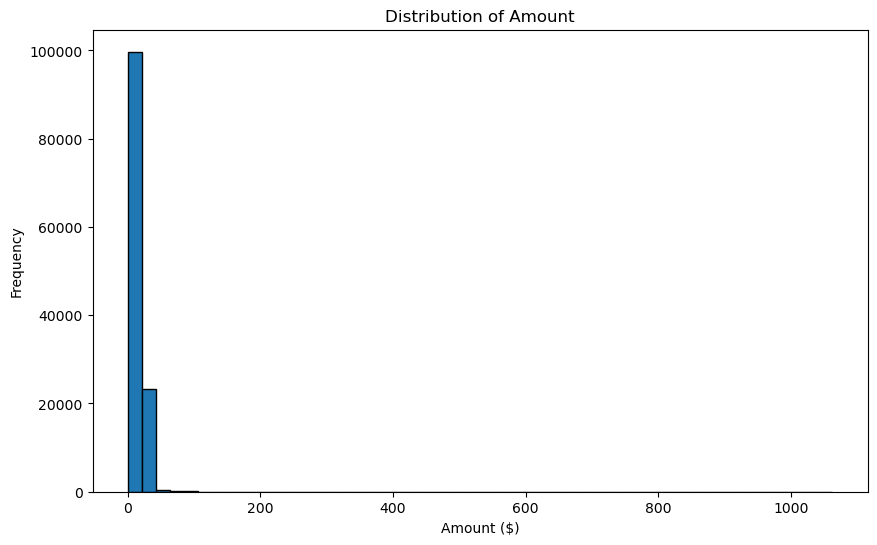

IQR lower_bound: -19.544999999999998 | upper_bound: 42.334999999999994


count    123957.000000
mean         13.996325
std          31.749420
min           0.050000
25%           3.660000
50%          10.800000
75%          19.130000
max        1062.280000
Name: amount, dtype: float64

In [144]:
# 10) amount 분포 확인 + IQR 기반 이상치 경계 계산
df22 = df21.copy()
amount_data = df22['amount'].dropna()

plt.figure(figsize = (10, 6))
plt.hist(amount_data, bins = 50, edgecolor = 'black')
plt.title('Distribution of Amount')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.show()

Q1 = amount_data.quantile(0.25)
Q3 = amount_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR lower_bound:", lower_bound, "| upper_bound:", upper_bound)
display(amount_data.describe())

In [145]:
# 11) 이상치 제거 적용(기존과 동일하게 0.05 ~ 41 범위 사용 + amount NaN 유지)
df22_fin = df22[
    df22["amount"].isna() |
    (df22["amount"].between(0.05, 41))
].copy()

print("amount 결측 행 개수:", df22_fin['amount'].isna().sum())
display(df22_fin['amount'].describe())

amount 결측 행 개수: 148805


count    122792.000000
mean         12.159731
std           9.392234
min           0.050000
25%           3.620000
50%          10.640000
75%          18.872500
max          41.000000
Name: amount, dtype: float64

In [146]:
# 12) 최종 마스터 테이블 저장
df22_fin.to_csv('prep_master_table.csv', index = False, encoding = 'utf-8-sig')
f_mt = df22_fin.copy()
f_mt

,person,event,time,amount,offer_id,reward,gender,age,became_member_on,income,...,reward_offer,channels,difficulty,duration,offer_type,email,mobile,social,web,duration_hr
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,F,75,2017-05-09,100000.0,...,5.0,"[web, email, mobile]",5.0,7.0,bogo,1.0,1.0,0.0,1.0,168.0
1,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,M,68,2018-04-26,70000.0,...,2.0,"[web, email, mobile]",10.0,7.0,discount,1.0,1.0,0.0,1.0,168.0
2,389bc3fa690240e798340f5a15918d5c,offer received,0,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN,M,65,2018-02-09,53000.0,...,5.0,"[web, email, mobile, social]",5.0,5.0,bogo,1.0,1.0,1.0,1.0,120.0
3,2eeac8d8feae4a8cad5a6af0499a211d,offer received,0,NaN,3f207df678b143eea3cee63160fa8bed,NaN,M,58,2017-11-11,51000.0,...,0.0,"[web, email, mobile]",0.0,4.0,informational,1.0,1.0,0.0,1.0,96.0
4,aa4862eba776480b8bb9c68455b8c2e1,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,F,61,2017-09-11,57000.0,...,5.0,"[web, email]",20.0,10.0,discount,1.0,0.0,0.0,1.0,240.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272757,24f56b5e1849462093931b164eb803b5,offer completed,714,NaN,fafdcd668e3743c1bb461111dcafc2a4,2.0,F,48,2017-12-28,80000.0,...,2.0,"[web, email, mobile, social]",10.0,10.0,discount,1.0,1.0,1.0,1.0,240.0
272758,b3a1272bc9904337b331bf348c3e8c17,transaction,714,1.59,NaN,NaN,M,66,2018-01-01,47000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
272759,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,9.53,NaN,NaN,M,52,2018-04-08,62000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
272760,a00058cf10334a308c68e7631c529907,transaction,714,3.61,NaN,NaN,F,63,2013-09-22,52000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
# 1) offer received 기준으로 "오퍼 인스턴스" 생성
# 각 received에 대해 viewed/ completed / transaction을 시간창(window)으로 매칭
# success / cost_paid / is_waste 라벨 생성

# 핵심 아이디어
# 한 번의 offer received을 분석 단위로 만든다.
# viewed: received 이후 최초 viewed가 window 안에 있으면 1
# completed: view 이후 최초 completed가 window 안에 있으면 1
# blind_txn: view 이전(or 아예 view 없이) window 내 거래가 있으면 1

# success 정의
# - informational: viewed + view 이후 구매
# - bogo/discount: viewed + completed
# - is_waste(낭비): (안 봄) or (성공 못함) or (blind 구매 있음)

def build_offer_instances_v1(df):
    df = df.copy()

    # time 정리
    df["time"] = pd.to_numeric(df["time"], errors = "coerce")
    df = df.dropna(subset = ["time"]).copy()
    df["time"] = df["time"].astype(np.int64)

    # duration_hr 생성
    df["duration_hr"] = pd.to_numeric(df["duration"], errors = "coerce").fillna(0).astype(int) * 24

    # offer meta 컬럼 자동 탐지
    offer_type_col = "offer_type" if "offer_type" in df.columns else "offer_type_offer"
    reward_col = "reward" if "reward" in df.columns else "reward_offer"
    difficulty_col = "difficulty" if "difficulty" in df.columns else "difficulty_offer"

    channel_cols = [c for c in ["web", "email", "mobile", "social"] if c in df.columns]
    demo_cols = [c for c in ["age_g", "income_g", "gender_g", "membership_g"] if c in df.columns]

    # 이벤트 테이블 분리
    received = df[df["event"] == "offer received"][["person", "offer_id", "time", "duration_hr"]].copy()
    received = received.rename(columns = {"time": "recv_time"})
    received["expire_time"] = received["recv_time"] + received["duration_hr"]

    viewed = df[df["event"] == "offer viewed"][["person", "offer_id", "time"]].copy()
    viewed = viewed.rename(columns = {"time": "view_time"})

    completed = df[df["event"] == "offer completed"][["person", "offer_id", "time"]].copy()
    completed = completed.rename(columns = {"time": "comp_time"})

    txn = df[df["event"] == "transaction"][["person", "time", "amount"]].copy()
    txn = txn.rename(columns = {"time": "txn_time"})
    txn["amount"] = pd.to_numeric(txn["amount"], errors = "coerce").fillna(0.0)

    # offer meta
    meta_cols = ["offer_id"]
    for c in [offer_type_col, reward_col, difficulty_col, "duration_hr"]:
        if c in df.columns and c not in meta_cols:
            meta_cols.append(c)
    meta_cols += [c for c in channel_cols if c not in meta_cols]

    offer_meta = df[df["offer_id"].notna()][meta_cols].drop_duplicates("offer_id").copy()
    offer_meta = offer_meta.rename(columns = {
        offer_type_col: "offer_type",
        reward_col: "reward",
        difficulty_col: "difficulty"
    })
    
    offer_meta["reward"] = pd.to_numeric(offer_meta.get("reward", 0), errors = "coerce").fillna(0.0)
    offer_meta["difficulty"] = pd.to_numeric(offer_meta.get("difficulty", 0), errors = "coerce").fillna(0.0)

    # demographic
    demo = df[["person"] + demo_cols].drop_duplicates("person").copy() if len(demo_cols) > 0 else None

    # person, offer_id 기준 lookup dict
    viewed_dict = {
        (p, oid): np.sort(g["view_time"].astype(np.int64).values)
        for (p, oid), g in viewed.groupby(["person", "offer_id"])
    }
    comp_dict = {
        (p, oid): np.sort(g["comp_time"].astype(np.int64).values)
        for (p, oid), g in completed.groupby(["person", "offer_id"])
    }

    txn_dict = {}
    for p, g in txn.sort_values(["person", "txn_time"]).groupby("person"):
        txn_dict[p] = (
            g["txn_time"].values.astype(np.int64),
            g["amount"].values.astype(float)
        )

    # received 단위로 window 매칭
    rows = []
    for r in received.itertuples(index = False):
        p = r.person
        oid = r.offer_id
        recv_time = int(r.recv_time)
        expire_time = int(r.expire_time)

        # 1) viewed: recv_time 이후 첫 viewed (expire_time 이내)
        v_arr = viewed_dict.get((p, oid))
        view_time = np.nan
        viewed_in_window = 0

        if v_arr is not None and len(v_arr) > 0:
            idx = np.searchsorted(v_arr, recv_time, side = "left")
            if idx < len(v_arr):
                vt = int(v_arr[idx])
                if vt <= expire_time:
                    view_time = vt
                    viewed_in_window = 1

        # 2) completed: view_time 이후 첫 completed
        c_arr = comp_dict.get((p, oid))
        comp_time = np.nan
        completed_in_window = 0

        if viewed_in_window == 1 and c_arr is not None and len(c_arr) > 0:
            idxc = np.searchsorted(c_arr, int(view_time), side = "left")
            if idxc < len(c_arr):
                ct = int(c_arr[idxc])
                if ct <= expire_time:
                    comp_time = ct
                    completed_in_window = 1

        # 3) transaction: window 내 blind 여부 + view 이후 txn 집계
        tinfo = txn_dict.get(p)
        blind_txn_in_window = 0
        txn_cnt_after_view = 0
        txn_amt_after_view = 0.0

        if tinfo is not None:
            t_arr, a_arr = tinfo

            l = np.searchsorted(t_arr, recv_time, side = "left")
            r2 = np.searchsorted(t_arr, expire_time, side = "right")

            if r2 > l:
                if viewed_in_window == 0 or np.isnan(view_time):
                    blind_txn_in_window = 1
                else:
                    if (t_arr[l:r2] < int(view_time)).any():
                        blind_txn_in_window = 1

            if viewed_in_window == 1 and not np.isnan(view_time):
                l2 = np.searchsorted(t_arr, int(view_time), side = "right")
                r3 = np.searchsorted(t_arr, expire_time, side = "right")
                if r3 > l2:
                    txn_cnt_after_view = int(r3 - l2)
                    txn_amt_after_view = float(a_arr[l2:r3].sum())

        rows.append({
            "person": p,
            "offer_id": oid,
            "recv_time": recv_time,
            "expire_time": expire_time,
            "duration_hr": int(r.duration_hr),
            "view_time": view_time,
            "comp_time": comp_time,
            "viewed_in_window": int(viewed_in_window),
            "completed_in_window": int(completed_in_window),
            "blind_txn_in_window": int(blind_txn_in_window),
            "txn_cnt_after_view": int(txn_cnt_after_view),
            "txn_amt_after_view": float(txn_amt_after_view),
        })

    inst = pd.DataFrame(rows)

    # meta + demo 붙이기
    inst = inst.merge(offer_meta, on = "offer_id", how = "left")
    if demo is not None:
        inst = inst.merge(demo, on = "person", how = "left")

    # success 정의
    inst["success"] = 0

    inst.loc[
        (inst["offer_type"] == "informational") &
        (inst["viewed_in_window"] == 1) &
        (inst["txn_amt_after_view"] > 0),
        "success"
    ] = 1

    inst.loc[
        (inst["offer_type"].isin(["bogo", "discount"])) &
        (inst["viewed_in_window"] == 1) &
        (inst["completed_in_window"] == 1),
        "success"
    ] = 1

    # 비용: bogo/discount 성공 시 reward 지급 가정
    inst["cost_paid"] = 0.0
    inst.loc[
        (inst["offer_type"].isin(["bogo", "discount"])) & (inst["success"] == 1),
        "cost_paid"
    ] = inst["reward"].fillna(0.0)

    # waste
    inst["is_waste"] = (
        (inst["viewed_in_window"] == 0) |
        (inst["success"] == 0) |
        (inst["blind_txn_in_window"] == 1)
    ).astype(int)

    # 컬럼 정리
    keep = [
        "person", "offer_id", "recv_time", "expire_time",
        "offer_type", "reward", "difficulty", "duration_hr"
    ] + channel_cols + demo_cols + [
        "viewed_in_window", "completed_in_window", "blind_txn_in_window",
        "txn_cnt_after_view", "txn_amt_after_view",
        "success", "cost_paid", "is_waste"
    ]
    keep = [c for c in keep if c in inst.columns]

    return inst[keep].copy()


df_inst = build_offer_instances_v1(f_mt)

print(df_inst.shape)
display(df_inst.head(10))

(66501, 23)


,person,offer_id,recv_time,expire_time,offer_type,reward,difficulty,web,email,mobile,...,gender_g,membership_g,viewed_in_window,completed_in_window,blind_txn_in_window,txn_cnt_after_view,txn_amt_after_view,success,cost_paid,is_waste
0,78afa995795e4d85b5d9ceeca43f5fef,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,168,bogo,0.0,5.0,1.0,1.0,1.0,...,F,1~3yr,1,1,0,2,37.67,1,0.0,0
1,e2127556f4f64592b11af22de27a7932,2906b810c7d4411798c6938adc9daaa5,0,168,discount,0.0,10.0,1.0,1.0,1.0,...,M,Under 1yr,1,0,0,0,0.00,0,0.0,1
2,389bc3fa690240e798340f5a15918d5c,f19421c1d4aa40978ebb69ca19b0e20d,0,120,bogo,0.0,5.0,1.0,1.0,1.0,...,M,Under 1yr,1,1,0,1,9.54,1,0.0,0
3,2eeac8d8feae4a8cad5a6af0499a211d,3f207df678b143eea3cee63160fa8bed,0,96,informational,0.0,0.0,1.0,1.0,1.0,...,M,Under 1yr,0,0,0,0,0.00,0,0.0,1
4,aa4862eba776480b8bb9c68455b8c2e1,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,240,discount,0.0,20.0,1.0,1.0,0.0,...,F,Under 1yr,1,0,0,1,12.33,0,0.0,1
5,31dda685af34476cad5bc968bdb01c53,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,240,discount,0.0,20.0,1.0,1.0,0.0,...,F,1~3yr,1,0,0,0,0.00,0,0.0,1
6,4b0da7e80e5945209a1fdddfe813dbe0,ae264e3637204a6fb9bb56bc8210ddfd,0,168,bogo,0.0,10.0,0.0,1.0,1.0,...,M,Under 1yr,1,0,0,0,0.00,0,0.0,1
7,c27e0d6ab72c455a8bb66d980963de60,3f207df678b143eea3cee63160fa8bed,0,96,informational,0.0,0.0,1.0,1.0,1.0,...,F,1~3yr,1,0,0,1,18.90,1,0.0,0
8,d53717f5400c4e84affdaeda9dd926b3,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,240,discount,0.0,20.0,1.0,1.0,0.0,...,F,1~3yr,1,1,0,4,51.61,1,0.0,0
9,f806632c011441378d4646567f357a21,fafdcd668e3743c1bb461111dcafc2a4,0,240,discount,0.0,10.0,1.0,1.0,1.0,...,M,3yr+,1,1,0,2,41.23,1,0.0,0


In [148]:
# 2) transaction dict 준비

mt = f_mt.copy()
mt["time"] = pd.to_numeric(mt["time"], errors = "coerce")
mt = mt.dropna(subset = ["time"]).copy()
mt["time"] = mt["time"].astype(np.int64)

txn = mt[mt["event"] == "transaction"][["person", "time", "amount"]].copy()
txn = txn.rename(columns = {"time": "txn_time"})
txn["amount"] = pd.to_numeric(txn["amount"], errors = "coerce").fillna(0.0)

txn_dict = {}
for p, g in txn.sort_values(["person", "txn_time"]).groupby("person"):
    txn_dict[p] = (
        g["txn_time"].values.astype(np.int64),
        g["amount"].values.astype(float)
    )

print("txn rows:", txn.shape)

txn rows: (122792, 3)


In [149]:
# 3) 과거 30/60/90일 구매횟수/매출

H30 = 30 * 24
H60 = 60 * 24
H90 = 90 * 24

def past_window_stats(p, t0, hours):
    info = txn_dict.get(p)
    if info is None:
        return 0, 0.0

    t_arr, a_arr = info
    left = np.searchsorted(t_arr, t0 - hours, side = "left")
    right = np.searchsorted(t_arr, t0, side = "left")
    if right <= left:
        return 0, 0.0

    return int(right - left), float(a_arr[left:right].sum())


df_feat = df_inst.copy()
df_feat["recv_time"] = df_feat["recv_time"].astype(np.int64)

cnt30, amt30, cnt60, amt60, cnt90, amt90 = [], [], [], [], [], []
for r in df_feat.itertuples(index = False):
    c, a = past_window_stats(r.person, int(r.recv_time), H30); cnt30.append(c); amt30.append(a)
    c, a = past_window_stats(r.person, int(r.recv_time), H60); cnt60.append(c); amt60.append(a)
    c, a = past_window_stats(r.person, int(r.recv_time), H90); cnt90.append(c); amt90.append(a)

df_feat["txn_cnt_30d"] = cnt30
df_feat["txn_amt_30d"] = amt30
df_feat["txn_cnt_60d"] = cnt60
df_feat["txn_amt_60d"] = amt60
df_feat["txn_cnt_90d"] = cnt90
df_feat["txn_amt_90d"] = amt90

display(df_feat[[
    "txn_cnt_30d", "txn_amt_30d",
    "txn_cnt_60d", "txn_amt_60d",
    "txn_cnt_90d", "txn_amt_90d"
]].describe())

,txn_cnt_30d,txn_amt_30d,txn_cnt_60d,txn_amt_60d,txn_cnt_90d,txn_amt_90d
count,66501.000000,66501.000000,66501.000000,66501.000000,66501.000000,66501.000000
mean,3.506474,42.664044,3.506474,42.664044,3.506474,42.664044
std,3.707048,53.738688,3.707048,53.738688,3.707048,53.738688
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,21.180000,3.000000,21.180000,3.000000,21.180000
75%,5.000000,65.330000,5.000000,65.330000,5.000000,65.330000
max,28.000000,402.970000,28.000000,402.970000,28.000000,402.970000


In [150]:
# 4) 개인별 과거 반응률/낭비율

df_feat = df_feat.sort_values(["person", "recv_time"]).reset_index(drop = True)
g = df_feat.groupby("person", sort = False)

df_feat["hist_offer_cnt"] = g.cumcount()

df_feat["hist_success_rate"] = g["success"].apply(lambda s: s.shift(1).expanding().mean()).reset_index(level = 0, drop = True)
df_feat["hist_view_rate"] = g["viewed_in_window"].apply(lambda s: s.shift(1).expanding().mean()).reset_index(level = 0, drop = True)
df_feat["hist_waste_rate"] = g["is_waste"].apply(lambda s: s.shift(1).expanding().mean()).reset_index(level = 0, drop = True)

for c in ["hist_success_rate", "hist_view_rate", "hist_waste_rate"]:
    df_feat[c] = df_feat[c].fillna(0.0)

df_feat["true_loyalty_rate"] = g["blind_txn_in_window"].apply(lambda s: s.shift(1).expanding().mean()).reset_index(level = 0, drop = True)
df_feat["true_loyalty_rate"] = df_feat["true_loyalty_rate"].fillna(0.0)

display(df_feat[[
    "hist_offer_cnt", "hist_success_rate", "hist_view_rate", "hist_waste_rate", "true_loyalty_rate"
]].describe())

,hist_offer_cnt,hist_success_rate,hist_view_rate,hist_waste_rate,true_loyalty_rate
count,66501.000000,66501.000000,66501.000000,66501.00000,66501.000000
mean,1.871596,0.327322,0.580204,0.47085,0.208647
std,1.453285,0.388888,0.426579,0.42526,0.312408
min,0.000000,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.000000,0.000000,0.00000,0.000000
50%,2.000000,0.000000,0.666667,0.50000,0.000000
75%,3.000000,0.666667,1.000000,1.00000,0.333333
max,5.000000,1.000000,1.000000,1.00000,1.000000


In [151]:
# 5) 평균 구매 간격(시간) - recv_time 이전 txn로 계산
def avg_gap_before(p, t0, max_lookback_hours = 90 * 24):
    info = txn_dict.get(p)
    if info is None:
        return np.nan

    t_arr, _ = info
    left = np.searchsorted(t_arr, t0 - max_lookback_hours, side = "left")
    right = np.searchsorted(t_arr, t0, side = "left")

    t_hist = t_arr[left:right]
    if len(t_hist) < 2:
        return np.nan

    return float(np.mean(np.diff(t_hist)))

avg_gap = []
for r in df_feat.itertuples(index = False):
    avg_gap.append(avg_gap_before(r.person, int(r.recv_time), 90 * 24))

df_feat["avg_purchase_gap_hr_90d"] = avg_gap

median_gap = df_feat["avg_purchase_gap_hr_90d"].median()
df_feat["avg_purchase_gap_hr_90d"] = df_feat["avg_purchase_gap_hr_90d"].fillna(median_gap)

display(df_feat["avg_purchase_gap_hr_90d"].describe())

count    66501.000000
mean        73.285148
std         46.722425
min          6.000000
25%         54.000000
50%         63.000000
75%         75.000000
max        534.000000
Name: avg_purchase_gap_hr_90d, dtype: float64

In [152]:
# 6) 모델 학습용 테이블 생성 (X, y)

target_col = "is_waste"

cat_cols = [c for c in ["offer_type", "age_g", "income_g", "gender_g", "membership_g"] if c in df_feat.columns]
num_cols = [
    "reward", "difficulty", "duration_hr",
    "txn_cnt_30d", "txn_amt_30d", "txn_cnt_60d", "txn_amt_60d", "txn_cnt_90d", "txn_amt_90d",
    "hist_offer_cnt", "hist_success_rate", "hist_view_rate", "hist_waste_rate", "true_loyalty_rate",
    "avg_purchase_gap_hr_90d"]

num_cols = [c for c in num_cols if c in df_feat.columns]

model_df = df_feat[["person", "offer_id", "recv_time"] + cat_cols + num_cols + [target_col]].copy()

X = pd.get_dummies(model_df[cat_cols + num_cols], columns = cat_cols, drop_first = False)
y = model_df[target_col].astype(int)

print("X shape:", X.shape, "| y mean(waste rate):", round(y.mean(), 3))

X shape: (66501, 35) | y mean(waste rate): 0.614


In [153]:
# 7) 모델 학습 + 평가 (TH = 0.5) + Negative Targeting 결과 생성
TH = 0.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print("train:", X_train.shape, "test:", X_test.shape)
print("train waste rate:", round(y_train.mean(), 3), "test waste rate:", round(y_test.mean(), 3))

train: (53200, 35) test: (13301, 35)
train waste rate: 0.614 test waste rate: 0.614


In [154]:
# Logistic Regression
from xgboost import XGBClassifier
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

logit = LogisticRegression(max_iter = 2000)
logit.fit(X_train_sc, y_train)

proba_logit = logit.predict_proba(X_test_sc)[:, 1]
pred_logit = (proba_logit >= TH).astype(int)

print(f"\n[Logistic] threshold = {TH}")
print("ROC-AUC:", round(roc_auc_score(y_test, proba_logit), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_logit))
print("Report:\n", classification_report(y_test, pred_logit))

# RandomForest

rf = RandomForestClassifier(
    n_estimators = 500,
    random_state = 42,
    n_jobs = -1,
    class_weight = "balanced_subsample"
)
rf.fit(X_train, y_train)

proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf >= TH).astype(int)

print(f"\n[RandomForest] threshold = {TH}")
print("ROC-AUC:", round(roc_auc_score(y_test, proba_rf), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_rf))
print("Report:\n", classification_report(y_test, pred_rf))

rf_imp = pd.Series(rf.feature_importances_, index = X.columns).sort_values(ascending = False)
print("\n[RF TOP15 Features]")
display(rf_imp.head(15))



# XGBoost

xgb = XGBClassifier(
    n_estimators = 600,
    learning_rate = 0.05,
    max_depth = 5,
    subsample = 0.9,
    colsample_bytree = 0.9,
    random_state = 42,
    n_jobs = -1,
    eval_metric = "logloss"
)

xgb.fit(X_train, y_train)

proba_xgb = xgb.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb >= TH).astype(int)

print(f"\n[XGBoost] threshold = {TH}")
print("ROC-AUC:", round(roc_auc_score(y_test, proba_xgb), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_xgb))
print("Report:\n", classification_report(y_test, pred_xgb))

# LightGBM

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators = 800,
    learning_rate = 0.05,
    num_leaves = 31,
    subsample = 0.9,
    colsample_bytree = 0.9,
    random_state = 42,
    n_jobs = -1)

lgbm.fit(X_train, y_train)

proba_lgb = lgbm.predict_proba(X_test)[:, 1]
pred_lgb = (proba_lgb >= TH).astype(int)

print(f"\n[LightGBM] threshold = {TH}")
print("ROC-AUC:", round(roc_auc_score(y_test, proba_lgb), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_lgb))
print("Report:\n", classification_report(y_test, pred_lgb))


# Negative Targeting

waste_proba_all = rf.predict_proba(X)[:, 1]
negative_target = (waste_proba_all >= TH).astype(int)

df_negative = model_df[["person", "offer_id", "recv_time", "is_waste"]].copy()
if "offer_type" in model_df.columns:
    df_negative["offer_type"] = model_df["offer_type"]

df_negative["waste_proba"] = waste_proba_all
df_negative["negative_target"] = negative_target

print(f"\n[Negative targeting rate @ TH = {TH}] :", round(df_negative["negative_target"].mean(), 3))
display(df_negative.sort_values("waste_proba", ascending = False).head(20))


[Logistic] threshold = 0.5
ROC-AUC: 0.714
Confusion Matrix:
 [[2234 2897]
 [1370 6800]]
Report:
               precision    recall  f1-score   support

           0       0.62      0.44      0.51      5131
           1       0.70      0.83      0.76      8170

    accuracy                           0.68     13301
   macro avg       0.66      0.63      0.64     13301
weighted avg       0.67      0.68      0.66     13301


[RandomForest] threshold = 0.5
ROC-AUC: 0.729
Confusion Matrix:
 [[2738 2393]
 [1843 6327]]
Report:
               precision    recall  f1-score   support

           0       0.60      0.53      0.56      5131
           1       0.73      0.77      0.75      8170

    accuracy                           0.68     13301
   macro avg       0.66      0.65      0.66     13301
weighted avg       0.68      0.68      0.68     13301


[RF TOP15 Features]


txn_amt_60d                0.102961
txn_amt_30d                0.102656
txn_amt_90d                0.102498
avg_purchase_gap_hr_90d    0.079154
difficulty                 0.073798
hist_offer_cnt             0.039985
hist_view_rate             0.033280
hist_waste_rate            0.032670
txn_cnt_60d                0.031992
txn_cnt_90d                0.031858
txn_cnt_30d                0.031783
true_loyalty_rate          0.029616
hist_success_rate          0.028681
membership_g_1~3yr         0.027330
membership_g_Under 1yr     0.025365
dtype: float64


[XGBoost] threshold = 0.5
ROC-AUC: 0.76
Confusion Matrix:
 [[2773 2358]
 [1564 6606]]
Report:
               precision    recall  f1-score   support

           0       0.64      0.54      0.59      5131
           1       0.74      0.81      0.77      8170

    accuracy                           0.71     13301
   macro avg       0.69      0.67      0.68     13301
weighted avg       0.70      0.71      0.70     13301

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 32678, number of negative: 20522
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000530 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1195
[LightGBM] [Info] Number of data points in the train set: 53200, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.614248 -> initscore=0.4

,person,offer_id,recv_time,is_waste,offer_type,waste_proba,negative_target
4487,1198b4f74e174c48b89a45b877c9d039,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,1,discount,1.0,1
51408,c53c106e77ea4b72ad89c3e1897b3449,0b1e1539f2cc45b7b9fa7c272da2e1d7,168,1,discount,1.0,1
31582,7a153a17d9754d3686c37684146fb681,5a8bc65990b245e5a138643cd4eb9837,0,1,informational,1.0,1
34017,8319fc0fd5294e6daf21fe0b1116c71e,4d5c57ea9a6940dd891ad53e9dbe8da0,504,1,bogo,1.0,1
51714,c6a21e05ec2d44669822677cb4fa4aba,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,1,discount,1.0,1
21725,535af760b9b743618f3f7f3ff6bb770b,ae264e3637204a6fb9bb56bc8210ddfd,0,1,bogo,1.0,1
58782,e211ccfbd319454490cbfbeeb6f3da5e,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,1,discount,1.0,1
11846,2eb7ed92af71400fa3148056c388ca1b,f19421c1d4aa40978ebb69ca19b0e20d,168,1,bogo,1.0,1
58783,e211ccfbd319454490cbfbeeb6f3da5e,fafdcd668e3743c1bb461111dcafc2a4,336,1,discount,1.0,1
1922,07b3cbbeea81414b9024bea5bc229daa,4d5c57ea9a6940dd891ad53e9dbe8da0,576,1,bogo,1.0,1


In [155]:
# 8) Offer Type × Customer Type Interaction

df_inter = df_feat.reset_index(drop = True).copy()
df_inter["waste_proba"] = rf.predict_proba(X)[:, 1]
df_inter["pred_waste"] = (df_inter["waste_proba"] >= TH).astype(int)

seg_cols = [c for c in ["income_g", "membership_g", "age_g", "gender_g"] if c in df_inter.columns]

if len(seg_cols) >= 2:
    df_inter["customer_type"] = df_inter[seg_cols].astype(str).agg("_".join, axis = 1)
elif len(seg_cols) == 1:
    df_inter["customer_type"] = df_inter[seg_cols[0]].astype(str)
else:
    df_inter["customer_type"] = "ALL"

print("customer_type using:", seg_cols)

pivot_actual = (
    df_inter.groupby(["customer_type", "offer_type"]).agg(
        n = ("person", "size"),
        actual_waste_rate = ("is_waste", "mean"),
        actual_success_rate = ("success", "mean"),
        avg_cost = ("cost_paid", "mean"),
        avg_txn_after = ("txn_amt_after_view", "mean")
    )
    .reset_index()
)

pivot_pred = (
    df_inter
    .groupby(["customer_type", "offer_type"])
    .agg(
        pred_waste_rate = ("pred_waste", "mean"),
        avg_waste_proba = ("waste_proba", "mean")
    )
    .reset_index()
)

pivot = pivot_actual.merge(pivot_pred, on = ["customer_type", "offer_type"], how = "left")

MIN_N = 200
pivot_f = pivot[pivot["n"] >= MIN_N].copy()

print(f"[Interaction summary] rows = {pivot.shape[0]} | filtered(n >= {MIN_N}) rows = {pivot_f.shape[0]}")
display(pivot_f.sort_values(["customer_type", "offer_type"]).head(30))


# 세그먼트 내 offer_type별 waste 확률 순위
pivot_ranked = pivot_f.copy()
pivot_ranked["rank_high_waste"] = pivot_ranked.groupby("customer_type")["avg_waste_proba"].rank(ascending = False, method = "dense")
pivot_ranked["rank_low_waste"] = pivot_ranked.groupby("customer_type")["avg_waste_proba"].rank(ascending = True, method = "dense")

worst = pivot_ranked[pivot_ranked["rank_high_waste"] == 1].copy()
best = pivot_ranked[pivot_ranked["rank_low_waste"] == 1].copy()

worst = worst.rename(columns = {
    "offer_type": "worst_offer_type",
    "avg_waste_proba": "worst_avg_waste_proba",
    "pred_waste_rate": "worst_pred_waste_rate",
    "actual_waste_rate": "worst_actual_waste_rate",
    "n": "worst_n"
})

best = best.rename(columns = {
    "offer_type": "best_offer_type",
    "avg_waste_proba": "best_avg_waste_proba",
    "pred_waste_rate": "best_pred_waste_rate",
    "actual_waste_rate": "best_actual_waste_rate",
    "n": "best_n"
})

interaction_delta = worst.merge(
    best[[
        "customer_type",
        "best_offer_type", "best_avg_waste_proba",
        "best_pred_waste_rate", "best_actual_waste_rate",
        "best_n"
    ]],
    on = "customer_type",
    how = "inner"
)

interaction_delta["delta_avg_waste_proba"] = interaction_delta["worst_avg_waste_proba"] - interaction_delta["best_avg_waste_proba"]
interaction_delta["delta_pred_waste_rate"] = interaction_delta["worst_pred_waste_rate"] - interaction_delta["best_pred_waste_rate"]
interaction_delta["delta_actual_waste_rate"] = interaction_delta["worst_actual_waste_rate"] - interaction_delta["best_actual_waste_rate"]

print("\n[Offer Type switching impact within each customer_type]")
display(interaction_delta.sort_values("delta_avg_waste_proba", ascending = False))

customer_type using: ['income_g', 'membership_g', 'age_g', 'gender_g']
[Interaction summary] rows = 588 | filtered(n >= 200) rows = 129


,customer_type,offer_type,n,actual_waste_rate,actual_success_rate,avg_cost,avg_txn_after,pred_waste_rate,avg_waste_proba
9,High-End_1~3yr_45-54_F,bogo,335,0.376119,0.626866,0.0,36.880209,0.250746,0.355444
10,High-End_1~3yr_45-54_F,discount,306,0.437908,0.568627,0.0,40.777680,0.375817,0.418043
12,High-End_1~3yr_45-54_M,bogo,249,0.373494,0.626506,0.0,34.903815,0.269076,0.348418
13,High-End_1~3yr_45-54_M,discount,222,0.373874,0.630631,0.0,49.076036,0.247748,0.373033
18,High-End_1~3yr_55-64_F,bogo,416,0.403846,0.600962,0.0,34.070937,0.331731,0.394873
19,High-End_1~3yr_55-64_F,discount,410,0.475610,0.553659,0.0,44.211659,0.439024,0.449734
20,High-End_1~3yr_55-64_F,informational,224,0.705357,0.325893,0.0,13.185670,0.790179,0.674359
21,High-End_1~3yr_55-64_M,bogo,273,0.377289,0.626374,0.0,35.032491,0.318681,0.388188
22,High-End_1~3yr_55-64_M,discount,295,0.406780,0.610169,0.0,45.594508,0.355932,0.384142
27,High-End_1~3yr_65+_F,bogo,573,0.425829,0.577661,0.0,33.170977,0.303665,0.395435



[Offer Type switching impact within each customer_type]


,customer_type,worst_offer_type,worst_n,worst_actual_waste_rate,actual_success_rate,avg_cost,avg_txn_after,worst_pred_waste_rate,worst_avg_waste_proba,rank_high_waste,rank_low_waste,best_offer_type,best_avg_waste_proba,best_pred_waste_rate,best_actual_waste_rate,best_n,delta_avg_waste_proba,delta_pred_waste_rate,delta_actual_waste_rate
4,High-End_1~3yr_65+_F,informational,276,0.699275,0.355072,0.0,12.618080,0.804348,0.686211,1.0,3.0,bogo,0.395435,0.303665,0.425829,573,0.290776,0.500683,0.273446
2,High-End_1~3yr_55-64_F,informational,224,0.705357,0.325893,0.0,13.185670,0.790179,0.674359,1.0,3.0,bogo,0.394873,0.331731,0.403846,416,0.279485,0.458448,0.301511
10,High-End_Under 1yr_65+_F,informational,226,0.800885,0.216814,0.0,7.263097,0.858407,0.761349,1.0,3.0,bogo,0.537296,0.536585,0.580488,410,0.224053,0.321822,0.220397
30,Mid-High_1~3yr_65+_F,informational,237,0.590717,0.447257,0.0,13.081392,0.704641,0.587937,1.0,3.0,bogo,0.384135,0.309524,0.404762,420,0.203802,0.395118,0.185955
38,Mid-High_Under 1yr_65+_F,informational,210,0.776190,0.257143,0.0,5.634381,0.852381,0.740925,1.0,3.0,discount,0.579263,0.596882,0.619154,449,0.161662,0.255499,0.157037
19,Low-End_Under 1yr_35-44_M,bogo,462,0.831169,0.181818,0.0,7.358766,0.876623,0.820323,1.0,3.0,informational,0.692121,0.797468,0.721519,237,0.128202,0.079155,0.109650
24,Low-End_Under 1yr_65+_M,bogo,572,0.849650,0.160839,0.0,6.068899,0.895105,0.844338,1.0,3.0,informational,0.720248,0.818868,0.743396,265,0.124090,0.076237,0.106254
18,Low-End_Under 1yr_25-34_M,bogo,472,0.828390,0.180085,0.0,6.659449,0.875000,0.806642,1.0,3.0,informational,0.692722,0.814655,0.706897,232,0.113919,0.060345,0.121493
58,VIP_1~3yr_65+_F,discount,338,0.529586,0.479290,0.0,40.263314,0.485207,0.529553,1.0,2.0,bogo,0.422675,0.325444,0.449704,338,0.106878,0.159763,0.079882
39,Mid-High_Under 1yr_65+_M,informational,222,0.774775,0.238739,0.0,4.861126,0.846847,0.763434,1.0,3.0,discount,0.656870,0.696903,0.676991,452,0.106565,0.149944,0.097784


In [156]:
# 세그먼트별 worst / best offer_type + 낭비 확률 테이블
seg_offer = pivot_f.copy()

# 세그먼트 내 낭비 확률 기준 순위
seg_offer["rank_high_waste"] = (
    seg_offer
    .groupby("customer_type")["avg_waste_proba"]
    .rank(ascending = False, method = "dense")
)

seg_offer["rank_low_waste"] = (
    seg_offer
    .groupby("customer_type")["avg_waste_proba"]
    .rank(ascending = True, method = "dense")
)

# worst / best 추출
worst = seg_offer[seg_offer["rank_high_waste"] == 1].copy()
best  = seg_offer[seg_offer["rank_low_waste"] == 1].copy()

# 컬럼 정리
worst = worst[[
    "customer_type",
    "offer_type",
    "avg_waste_proba"
]].rename(columns = {
    "offer_type": "worst_offer_type",
    "avg_waste_proba": "worst_waste_proba"
})

best = best[[
    "customer_type",
    "offer_type",
    "avg_waste_proba"
]].rename(columns = {
    "offer_type": "best_offer_type",
    "avg_waste_proba": "best_waste_proba"
})

# 하나의 테이블로 합치기
segment_offer_summary = worst.merge(
    best,
    on = "customer_type",
    how = "inner"
)

# 낭비 확률 차이
segment_offer_summary["waste_proba_gap"] = (
    segment_offer_summary["worst_waste_proba"]
    - segment_offer_summary["best_waste_proba"]
)

# 보기 좋게 정렬
segment_offer_summary = segment_offer_summary.sort_values(
    "waste_proba_gap", ascending = False
)

display(segment_offer_summary)

,customer_type,worst_offer_type,worst_waste_proba,best_offer_type,best_waste_proba,waste_proba_gap
4,High-End_1~3yr_65+_F,informational,0.686211,bogo,0.395435,0.290776
2,High-End_1~3yr_55-64_F,informational,0.674359,bogo,0.394873,0.279485
10,High-End_Under 1yr_65+_F,informational,0.761349,bogo,0.537296,0.224053
30,Mid-High_1~3yr_65+_F,informational,0.587937,bogo,0.384135,0.203802
38,Mid-High_Under 1yr_65+_F,informational,0.740925,discount,0.579263,0.161662
19,Low-End_Under 1yr_35-44_M,bogo,0.820323,informational,0.692121,0.128202
24,Low-End_Under 1yr_65+_M,bogo,0.844338,informational,0.720248,0.124090
18,Low-End_Under 1yr_25-34_M,bogo,0.806642,informational,0.692722,0.113919
58,VIP_1~3yr_65+_F,discount,0.529553,bogo,0.422675,0.106878
39,Mid-High_Under 1yr_65+_M,informational,0.763434,discount,0.656870,0.106565
